In [8]:
#IMPORTS

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import sys
from pathlib import Path
from types import SimpleNamespace

In [13]:
#paths

ROOT="/export/home/rstanciu/"
repo_path= ROOT + "FM_thesis_Razvan/FM_thesis/Mammo-FM/src/codebase"


#data

data_ROOT= ROOT + "ZGT_Mammo-FM_format"
test_ZGT_csv="detection_final_test.csv"
images_folder="images_png"


#model checkpoints


model_pretrained_path=ROOT + "FM_thesis_Razvan/FM_thesis/Mammo-FM/Mammo-FM_BatmanlabTrained_CLIP.tar"

model_ckpt_fold0= ROOT + "FM_thesis_Razvan/Mammo-FM/Mammo-FM_runs/fold0/checkpoints/custom/Concept-Detector/breast_clip_det_b5/lr_5e-05_epochs_40_concepts_Mass_alpha_0.25_gamma_2.0_score_th_0.1_data_frac_1.0_freeze_backbone_y/breast_clip_det_b5_seed_10_fold_0_best_auroc.pth"


In [7]:
#load state_dict and model

sys.path.append(str(repo_path))

from Detectors.retinanet.detector_model import RetinaNet_efficientnet
from Datasets.dataset_utils import get_dataloader_concept_detector


/export/home/rstanciu/FM_thesis_Razvan/FM_thesis/Mammo-FM/.venv-mammo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/export/home/rstanciu/FM_thesis_Razvan/FM_thesis/Mammo-FM/.venv-mammo/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [5]:
num_classes = 1  # change if your training used more classes
model_type = "breast_clip_det_b5"  

model = RetinaNet_efficientnet(
    num_classes=num_classes,
    model_type=model_type,
    clip_chk_pt=model_pretrained_path,
    freeze_backbone="n"
)

efficientnet-b5
GlobalParams(batch_norm_momentum=0.99, batch_norm_epsilon=0.001, dropout_rate=0.4, num_classes=1, width_coefficient=1.6, depth_coefficient=2.2, depth_divisor=8, min_depth=None, drop_connect_rate=0.2, image_size=456)
clip weights are loaded
Freezing the backbone of the image encode: n
Loaded pretrained weights for efficientnet-b5


In [6]:
checkpoint = torch.load(
    model_ckpt_fold0,
    map_location="cpu",
    weights_only=False
)

state_dict = checkpoint["state_dict"]


state_dict = {
    k.replace("module.", ""): v
    for k, v in state_dict.items()
}

model.load_state_dict(state_dict, strict=True)

<All keys matched successfully>

In [21]:
args = SimpleNamespace()

args.dataset = "custom"
args.model_type = "concept-detector"

test_df=pd.read_csv(f"{data_ROOT}/{test_ZGT_csv}")

args.valid_folds = test_df

args.batch_size = 1
args.num_workers = 0

args.resize = 512
args.alpha = 1.0
args.sigma = 50

args.concepts = ["Mass"]

args.mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
args.std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)

args.data_dir = Path(data_ROOT)
args.img_dir = Path(images_folder)


test_loader, test_dataset = get_dataloader_concept_detector(
    args,
    train=False
)

generating custom dataset loading


In [22]:
batch = next(iter(test_loader))

print(batch.keys())
print(batch["image"].shape)
print(batch["res_bbox_tensor"].shape)
print(batch["image_path"])

dict_keys(['image', 'res_bbox_tensor', 'image_path'])
torch.Size([1, 3, 512, 512])
torch.Size([1, 1, 5])
['/export/home/rstanciu/ZGT_Mammo-FM_format/images_png/1/1_L_CC.png']


/export/home/rstanciu/FM_thesis_Razvan/FM_thesis/Mammo-FM/src/codebase/Datasets/dataset_concepts.py:433: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor((image - self.mean) / self.std, dtype=torch.float32)


In [24]:
test_df.shape

(34, 18)

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)

        scores, labels, boxes = model(images)

        print(scores)
        print(labels)
        print(boxes)
        break

tensor([0.1004, 0.0941, 0.0843, 0.0760, 0.0673], device='cuda:0')
tensor([0, 0, 0, 0, 0], device='cuda:0')
tensor([[ 88.1731, 330.9647, 132.4223, 352.5934],
        [  0.0000,  36.4824,  29.6130,  60.7618],
        [274.7318, 279.6129, 309.3344, 308.6627],
        [ 78.7799, 320.6842, 140.8922, 358.5575],
        [  0.0000,  27.5294,  38.7817,  65.8222]], device='cuda:0')


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

def unnormalize_image(img, mean, std):
    """
    img: torch.Tensor [3, H, W]
    mean/std: tensor [3,1,1] or list of 3 values
    """
    img = img.detach().cpu()

    if not torch.is_tensor(mean):
        mean = torch.tensor(mean).view(3, 1, 1)
    if not torch.is_tensor(std):
        std = torch.tensor(std).view(3, 1, 1)

    mean = mean.cpu()
    std = std.cpu()

    img = img * std + mean
    img = img.clamp(0, 1)
    img = img.permute(1, 2, 0).numpy()

    return img


def visualize_gt_and_predictions(
    image,
    gt_boxes=None,
    pred_boxes=None,
    pred_scores=None,
    pred_labels=None,
    mean=None,
    std=None,
    score_thresh=0.05,
    class_names=None,
    figsize=(8, 8),
):
    """
    image: torch.Tensor [3, H, W]
    gt_boxes: torch.Tensor [N, 5] where columns are x1,y1,x2,y2,label
              or [N, 4]
    pred_boxes: torch.Tensor [M, 4]
    pred_scores: torch.Tensor [M]
    pred_labels: torch.Tensor [M]
    """

    if mean is not None and std is not None:
        img = unnormalize_image(image, mean, std)
    else:
        img = image.detach().cpu().permute(1, 2, 0).numpy()
        img = img.clip(0, 1)

    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(img, cmap="gray")

    # Ground truth boxes: green
    if gt_boxes is not None:
        gt_boxes = gt_boxes.detach().cpu()

        # remove padded -1 boxes
        gt_boxes = gt_boxes[gt_boxes[:, 0] >= 0]

        for box in gt_boxes:
            x1, y1, x2, y2 = box[:4].tolist()
            label = int(box[4].item()) if box.shape[0] >= 5 else None

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="lime",
                facecolor="none",
            )
            ax.add_patch(rect)

            text = "GT"
            if label is not None and class_names is not None:
                text += f": {class_names[label]}"

            ax.text(
                x1,
                y1,
                text,
                color="lime",
                fontsize=10,
                bbox=dict(facecolor="black", alpha=0.5),
            )

    # Predicted boxes: red
    if pred_boxes is not None and pred_scores is not None:
        pred_boxes = pred_boxes.detach().cpu()
        pred_scores = pred_scores.detach().cpu()

        if pred_labels is not None:
            pred_labels = pred_labels.detach().cpu()

        keep = pred_scores >= score_thresh

        pred_boxes = pred_boxes[keep]
        pred_scores = pred_scores[keep]

        if pred_labels is not None:
            pred_labels = pred_labels[keep]

        for i, box in enumerate(pred_boxes):
            x1, y1, x2, y2 = box.tolist()
            score = float(pred_scores[i])

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
            ax.add_patch(rect)

            text = f"Pred {score:.2f}"

            if pred_labels is not None and class_names is not None:
                label = int(pred_labels[i].item())
                text += f": {class_names[label]}"

            ax.text(
                x1,
                y2,
                text,
                color="red",
                fontsize=10,
                bbox=dict(facecolor="black", alpha=0.5),
            )

    ax.axis("off")
    plt.show()

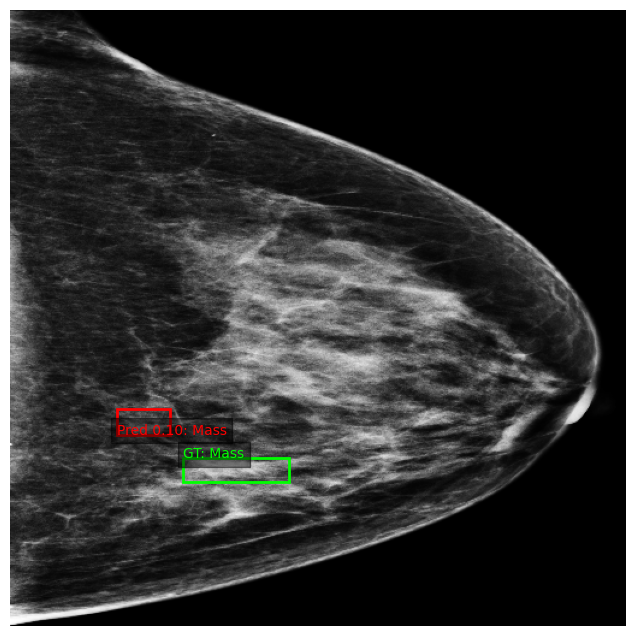

In [29]:
model.eval()

batch = next(iter(test_loader))

images = batch["image"].to(device)
gt_boxes = batch["res_bbox_tensor"]

with torch.no_grad():
    scores, labels, boxes = model(images)

visualize_gt_and_predictions(
    image=batch["image"][0],
    gt_boxes=gt_boxes[0],
    pred_boxes=boxes,
    pred_scores=scores,
    pred_labels=labels,
    mean=args.mean,
    std=args.std,
    score_thresh=0.1,
    class_names=args.concepts,
)